In [32]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV, RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from imblearn.pipeline import Pipeline as ImbPipeline

import numpy as np
import seaborn as sns
import pandas as pd
import sys
import os
import shap
import sys
import os

In [19]:
sys.path.insert(0, os.path.abspath(".."))
from src.pipeline import run_etl
from src.pipeline import DOMINIOS
df_tabla_0_imp, df_tabla_1_imp, df = run_etl("./../.env")

Descargando datos desde GitHub...
Hojas cargadas: 125
Tabla 0 (escolaridad baja) : 36
Tabla 1 (escolaridad alta) : 81
No determinadas            : 8
df_tabla_0 crudo : (36, 32)
df_tabla_1 crudo : (81, 29)

🔧  Imputando nulos...
--- Perfil nulos Tabla 0 ---
                                         nulos  %_nulos dtype  n_unicos
fluidez_verbal_semantica                    23    63.89   str         4
matrices                                    12    33.33   str         4
imagenes_sobrepuestas                       11    30.56   str         3
stroop_interferencia                         9    25.00   str         4
material_verbal_complejo                     6    16.67   str         3
denominacion                                 5    13.89   str         1
stroop_palabra                               4    11.11   str         4
stroop_color                                 4    11.11   str         4
atencion_sostenida_visual                    4    11.11   str         4
evocacion_diferida     

In [1]:
seed = 19971711

In [ ]:
models = {
    'SVC LINEAR': SVC(kernel='linear', class_weight='balanced', C=0.1, gamma='scale', random_state=seed),
    'RF': RandomForestClassifier(max_depth=4, n_estimators=200, min_samples_leaf=1, class_weight='balanced', max_features='sqrt', random_state=seed),
    'SVC RBF': SVC(kernel='rbf', C=10, gamma=0.01, class_weight='balanced', random_state=seed),
    'GB': GradientBoostingClassifier(learning_rate=0.1, max_depth=2,max_features='sqrt',min_samples_leaf=10, n_estimators=100, subsample=0.7, random_state=seed),
}

In [7]:
#Features para el modelo

DOMINIOS_COGNITIVOS = list(DOMINIOS.keys())
features = DOMINIOS_COGNITIVOS + ["age_num", "nivel_estudio"]
X = df[features]
y = pd.to_numeric(df["dc"], errors='coerce').fillna(-1).astype(int)

# Se filtran las filas que tengan etiquetas validas (0, 1, 2)
mask = y != -1
X = X[mask]
y = y[mask]

# Se establecen las métricas de evaluación más acordes, teniendo en cuenta que el dataset es pequeño y las clases estan desbalanceadas.
scoring = ['f1_macro', 'balanced_accuracy', 'matthews_corrcoef']

In [8]:
# Configuración de la validación cruzada estratificada repetida / debido a la naturaleza desbalanceada de las clases
cv_repeated_kfold = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=seed
) 
#Configuración de la validación cruzada estratificada / debido a la naturaleza desbalanceada de las clases
cv_kfold= StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

In [11]:
def train_model(model, X, y, cv):
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')), 
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])
    
    cv_scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, return_train_score=True)

    return cv_scores


In [12]:
# Resultados
results = []
results_overfitting = []

for model_name, model in models.items():
    cv_scores = train_model(model, X, y, cv_repeated_kfold)

    # medias para calcular la brecha entre entrenamiento y validación/test, para detectar sobreentrenamiento
    train_f1 = cv_scores['train_f1_macro'].mean()
    test_f1 = cv_scores['test_f1_macro'].mean()

    results_overfitting.append({
        "Modelo": model_name,
        "F1 (Entrenamiento)": train_f1,
        "F1 (Validación / Test)": test_f1,
        # Si la brecha es muy grande (> 0.15), hay sobreentrenamiento
        "Brecha (Caída)": train_f1 - test_f1,
        "F1 Validación (Std)": cv_scores['test_f1_macro'].std()
    })
    
    # Calcular y almacenar las medias y desviaciones estándar
    results.append({
        "Modelo": model_name,
        "F1-Score Macro": test_f1,
        "F1-Score (Std)": cv_scores['test_f1_macro'].std(),
        "Balanced Accuracy": cv_scores['test_balanced_accuracy'].mean(),
        "Bal. Acc. (Std)": cv_scores['test_balanced_accuracy'].std(),
        "Matthews Corr. Coef": cv_scores['test_matthews_corrcoef'].mean(),
        "MCC (Std)": cv_scores['test_matthews_corrcoef'].std()
    })


# Resultados, ordenados de mejor a peor
df_results = pd.DataFrame(results).sort_values(by="F1-Score Macro", ascending=False)
print("Resultados de los modelos")
print("-" * 70)
display(df_results.round(4))

# Resultados del overfitting
df_overfit = pd.DataFrame(results_overfitting).sort_values(by="F1 (Validación / Test)", ascending=False)
print("Analisis de overfitting")
print("-" * 85)
display(df_overfit.round(4))

Resultados de los modelos
----------------------------------------------------------------------


,Modelo,F1-Score Macro,F1-Score (Std),Balanced Accuracy,Bal. Acc. (Std),Matthews Corr. Coef,MCC (Std)
1,RF,0.7939,0.0848,0.8045,0.0865,0.6827,0.1320
0,SVC LINEAR,0.7928,0.0795,0.8126,0.0768,0.6867,0.1215
2,SVC RBF,0.7887,0.0859,0.8063,0.0830,0.6791,0.1315
3,GB,0.7737,0.0898,0.7685,0.0940,0.6548,0.1349


Analisis de overfitting
-------------------------------------------------------------------------------------


,Modelo,F1 (Entrenamiento),F1 (Validación / Test),Brecha (Caída),F1 Validación (Std)
1,RF,0.9700,0.7939,0.1762,0.0848
0,SVC LINEAR,0.8471,0.7928,0.0543,0.0795
2,SVC RBF,0.8705,0.7887,0.0819,0.0859
3,GB,0.9796,0.7737,0.2059,0.0898


In [14]:
def train_model_smote(model, X, y, cv):
    pipeline = ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')), 
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=seed)),
        ('classifier', model)
    ])
    
    cv_scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, return_train_score=True)

    return cv_scores


In [18]:
# Resultados con SMOTE
results = []
results_overfitting = []

for model_name, model in models.items():
    cv_scores = train_model(model, X, y, cv_repeated_kfold)

    # medias para calcular la brecha entre entrenamiento y validación/test, para detectar sobreentrenamiento
    train_f1 = cv_scores['train_f1_macro'].mean()
    test_f1 = cv_scores['test_f1_macro'].mean()

    results_overfitting.append({
        "Modelo": model_name,
        "F1 (Entrenamiento)": train_f1,
        "F1 (Validación / Test)": test_f1,
        # Si la brecha es muy grande (> 0.15), hay sobreentrenamiento
        "Brecha (Caída)": train_f1 - test_f1,
        "F1 Validación (Std)": cv_scores['test_f1_macro'].std()
    })
    
    # Calcular y almacenar las medias y desviaciones estándar
    results.append({
        "Modelo": model_name,
        "F1-Score Macro": test_f1,
        "F1-Score (Std)": cv_scores['test_f1_macro'].std(),
        "Balanced Accuracy": cv_scores['test_balanced_accuracy'].mean(),
        "Bal. Acc. (Std)": cv_scores['test_balanced_accuracy'].std(),
        "Matthews Corr. Coef": cv_scores['test_matthews_corrcoef'].mean(),
        "MCC (Std)": cv_scores['test_matthews_corrcoef'].std()
    })


# Resultados, ordenados de mejor a peor
df_results = pd.DataFrame(results).sort_values(by="F1-Score Macro", ascending=False)
print("Resultados de los modelos con SMOTE")
print("-" * 70)
display(df_results.round(4))

# Resultados del overfitting
df_overfit = pd.DataFrame(results_overfitting).sort_values(by="F1 (Validación / Test)", ascending=False)
print("Analisis de overfitting con SMOTE")
print("-" * 85)
display(df_overfit.round(4))

Resultados de los modelos con SMOTE
----------------------------------------------------------------------


,Modelo,F1-Score Macro,F1-Score (Std),Balanced Accuracy,Bal. Acc. (Std),Matthews Corr. Coef,MCC (Std)
0,SVC LINEAR,0.7928,0.0795,0.8126,0.0768,0.6867,0.1215
2,SVC RBF,0.7887,0.0859,0.8063,0.0830,0.6791,0.1315
1,RF,0.7836,0.0824,0.7986,0.0845,0.6685,0.1283
3,GB,0.7737,0.0898,0.7685,0.0940,0.6548,0.1349


Analisis de overfitting con SMOTE
-------------------------------------------------------------------------------------


,Modelo,F1 (Entrenamiento),F1 (Validación / Test),Brecha (Caída),F1 Validación (Std)
0,SVC LINEAR,0.8471,0.7928,0.0543,0.0795
2,SVC RBF,0.8705,0.7887,0.0819,0.0859
1,RF,0.9315,0.7836,0.1479,0.0824
3,GB,0.9796,0.7737,0.2059,0.0898


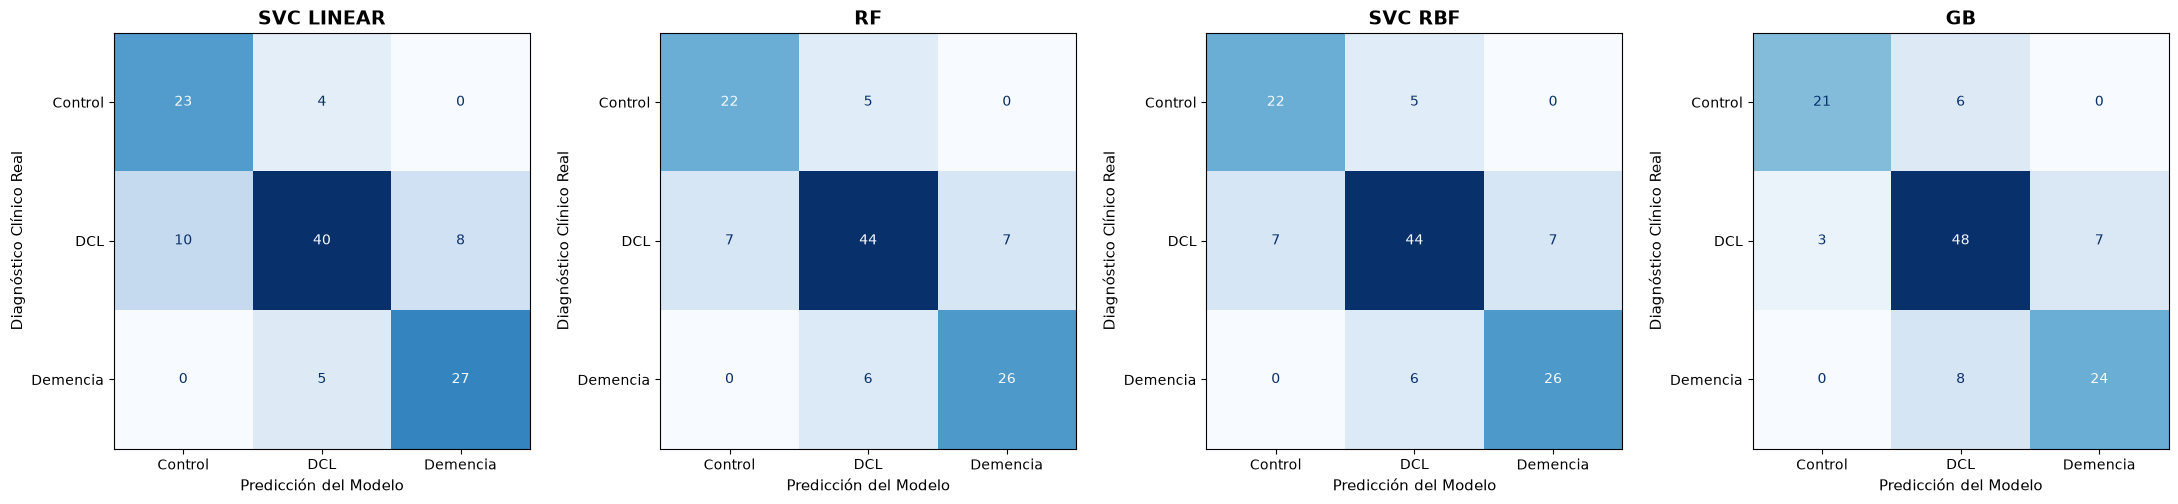

In [66]:
fig, axes = plt.subplots(1, len(models), figsize=(22, 5))

for ax, (name, model) in zip(axes, models.items()):
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')), 
        ('scaler', StandardScaler()),                 
        ('classifier', model)
    ])

    #Se generan de nuevo las predicciones para todo el dataset, pero cada paciente es evaluado solo cuando su fold fue el "fold de prueba".
    y_pred = cross_val_predict(pipeline, X, y, cv=cv_kfold)
    
    # Calculo de la matriz de confusión y visualización
    cm = confusion_matrix(y, y_pred, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control", "DCL", "Demencia"])

    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"{name}", fontweight="bold", fontsize=14)
    ax.set_xlabel("Predicción del Modelo", fontsize=11)
    ax.set_ylabel("Diagnóstico Clínico Real", fontsize=11)

plt.tight_layout()
plt.show()


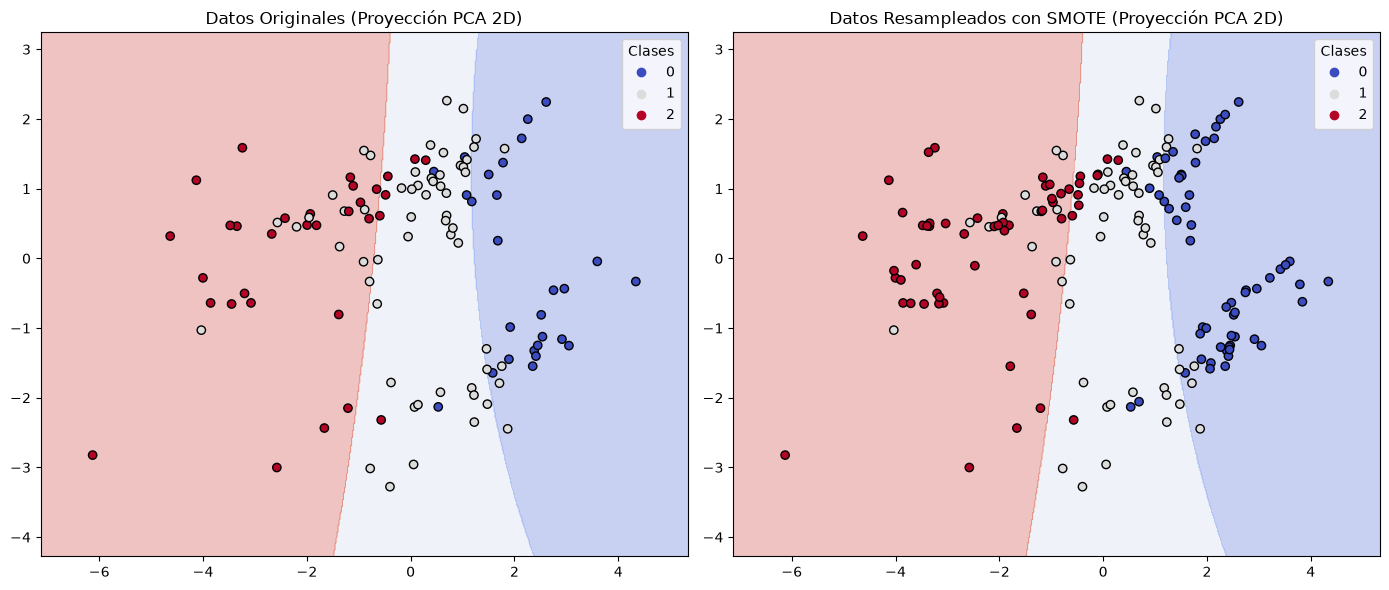

In [28]:
from sklearn.decomposition import PCA

#Preprocesar datos
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_clean = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_clean)

#Reducir dimensiones a 2D para visualización
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#Aplicar SMOTE en el espacio reducido (o en el original y luego reducir)
smote = SMOTE(random_state=seed)
X_res, y_res = smote.fit_resample(X_scaled, y)
X_res_pca = pca.transform(X_res)

#Entrenar el clasificador en el espacio 2D para graficar la frontera
clf = models['SVC RBF']  # Usar el modelo SVC RBF como ejemplo
clf.fit(X_res_pca, y_res)

# Crear malla para la frontera de decisión
x_min, x_max = X_res_pca[:, 0].min() - 1, X_res_pca[:, 0].max() + 1
y_min, y_max = X_res_pca[:, 1].min() - 1, X_res_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Datos Originales en 2D
axes[0].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
axes[0].set_title("Datos Originales (Proyección PCA 2D)")
axes[0].legend(*scatter0.legend_elements(), title="Clases")

#datos con SMOTE en 2D
axes[1].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter1 = axes[1].scatter(X_res_pca[:, 0], X_res_pca[:, 1], c=y_res, edgecolors='k', cmap=plt.cm.coolwarm)
axes[1].set_title("Datos Resampleados con SMOTE (Proyección PCA 2D)")
axes[1].legend(*scatter1.legend_elements(), title="Clases")

plt.tight_layout()
plt.show()


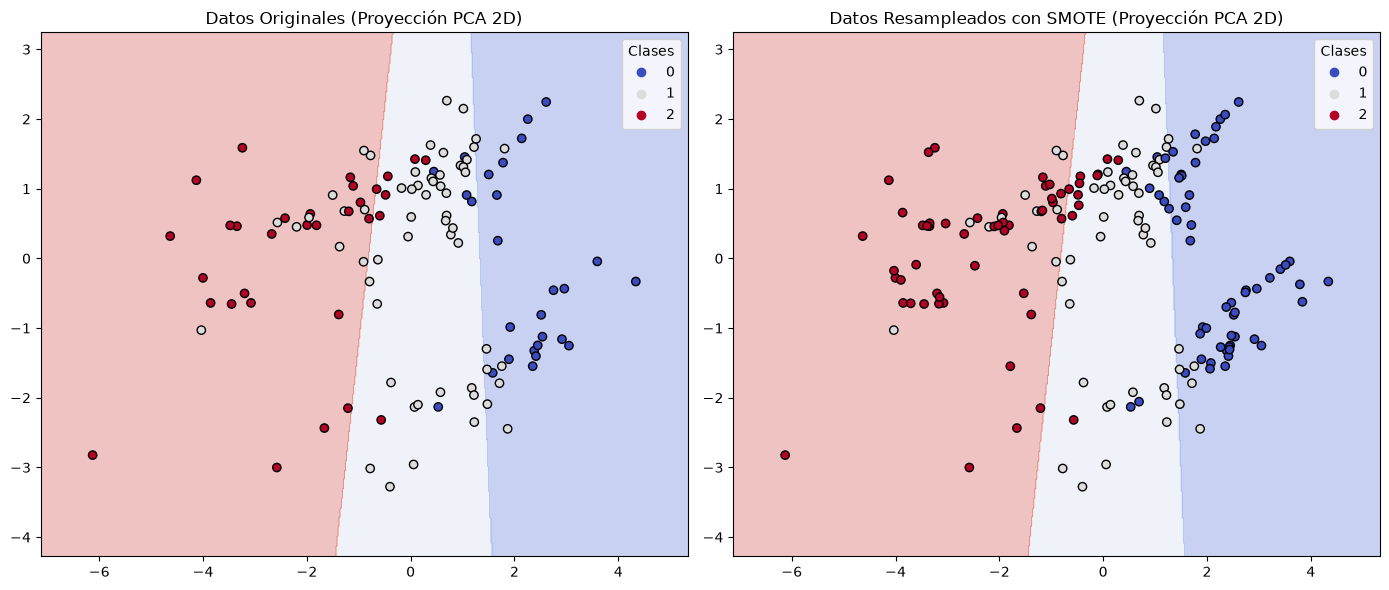

In [ ]:
#Preprocesar datos
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_clean = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_clean)

#Reducir dimensiones a 2D para visualización
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#Aplicar SMOTE en el espacio reducido (o en el original y luego reducir)
smote = SMOTE(random_state=seed)
X_res, y_res = smote.fit_resample(X_scaled, y)
X_res_pca = pca.transform(X_res)

#Entrenar el clasificador en el espacio 2D para graficar la frontera
clf = models['SVC LINEAR']  # Usar el modelo SVC RBF como ejemplo
clf.fit(X_res_pca, y_res)

# Crear malla para la frontera de decisión
x_min, x_max = X_res_pca[:, 0].min() - 1, X_res_pca[:, 0].max() + 1
y_min, y_max = X_res_pca[:, 1].min() - 1, X_res_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Datos Originales en 2D
axes[0].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
axes[0].set_title("Datos Originales (Proyección PCA 2D)")
axes[0].legend(*scatter0.legend_elements(), title="Clases")

#datos con SMOTE en 2D
axes[1].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter1 = axes[1].scatter(X_res_pca[:, 0], X_res_pca[:, 1], c=y_res, edgecolors='k', cmap=plt.cm.coolwarm)
axes[1].set_title("Datos Resampleados con SMOTE (Proyección PCA 2D)")
axes[1].legend(*scatter1.legend_elements(), title="Clases")

plt.tight_layout()
plt.show()


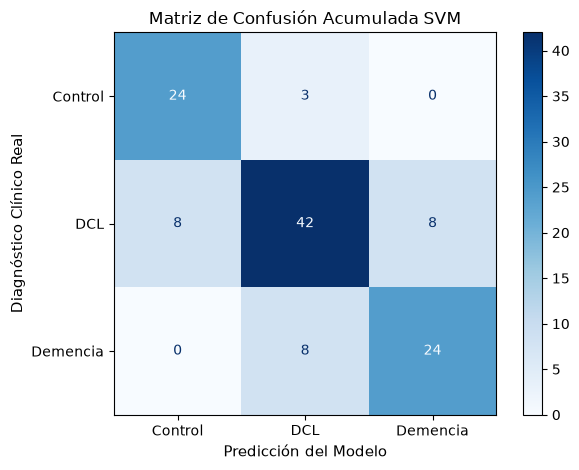

In [65]:
pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=seed)),
    ('classifier', models['SVC RBF'])
])

# Obtener predicciones por Validación Cruzada
y_pred = cross_val_predict(pipeline, X, y, cv=cv_kfold)

# Calcular y graficar matriz de confusión
cm = confusion_matrix(y, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control", "DCL", "Demencia"])
disp.plot(cmap=plt.cm.Blues)
plt.xlabel("Predicción del Modelo", fontsize=11)
plt.ylabel("Diagnóstico Clínico Real", fontsize=11)
plt.title("Matriz de Confusión Acumulada SVM")
plt.tight_layout()
plt.show()